(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   

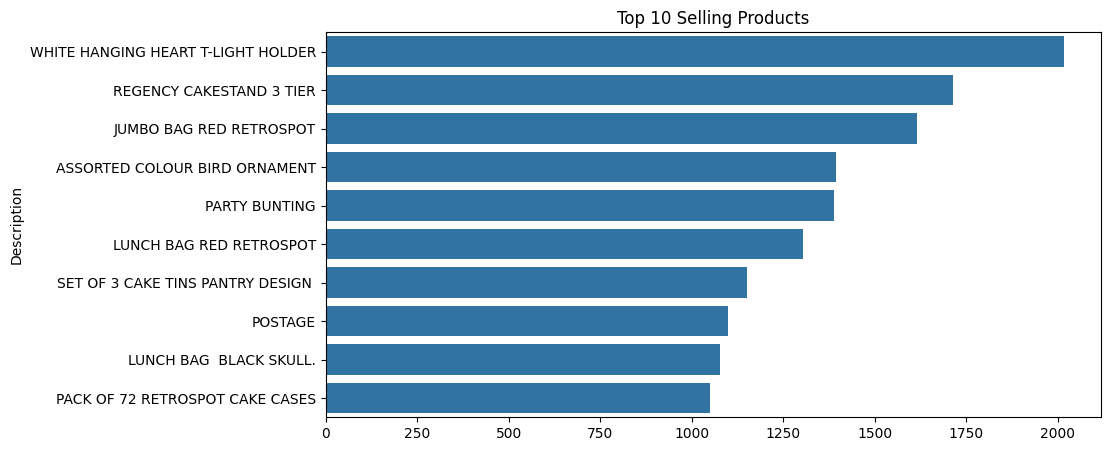

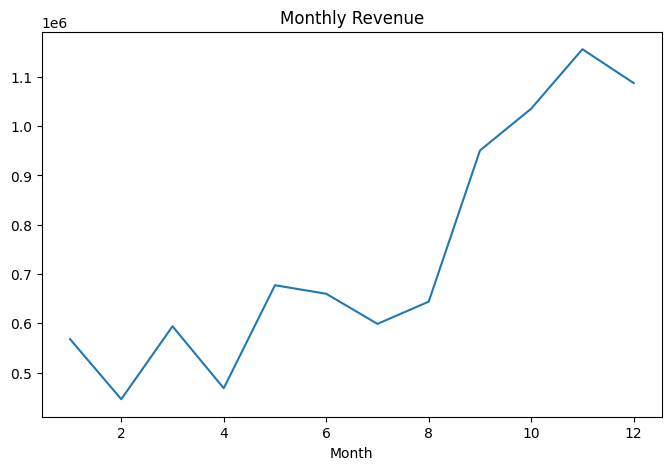

Cleaned data saved successfully!


In [5]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# LOAD DATA
# ===============================
df = pd.read_csv("OnlineRetail.csv",)

# ===============================
# BASIC INFO
# ===============================
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

# ===============================
# DATA CLEANING
# ===============================

# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Remove negative price
df = df[df['UnitPrice'] > 0]

# Remove duplicates
df = df.drop_duplicates()

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Cleaned Shape:", df.shape)

# ===============================
# FEATURE ENGINEERING
# ===============================

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Extract Year and Month
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

# ===============================
# EDA VISUALS
# ===============================

# Top 10 products
top_products = df['Description'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Selling Products")
plt.show()

# Revenue per month
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(8,5))
monthly_revenue.plot()
plt.title("Monthly Revenue")
plt.show()

# ===============================
# SAVE CLEANED DATA
# ===============================
df.to_csv("cleaned_retail.csv", index=False)

print("Cleaned data saved successfully!")
